# Colab Setup

**For Colab users:** Uncomment and run the cell below to mount Drive.  
**For local users:** Skip this cell.

In [14]:
# Uncomment for Colab:
#from google.colab import drive
#drive.mount('/content/drive')

## Setup: Dependency Verification and Installation

This cell checks for the presence of essential Python libraries (like `numpy`, `torch`, `musdb`, `nbformat`, etc.).
If any required library is not found, it attempts to install it automatically using `pip`.
It also verifies the availability of PyTorch with CUDA, which is crucial for GPU-accelerated training.

In [15]:
# --- 1. Verify and install dependencies ---
print("Verifying and installing missing packages if necessary...")

packages_to_check = [
    'numpy', 'matplotlib', 'librosa', 'tqdm', 'sklearn', 'stempeg', 'torch', 'torchvision', 'torchaudio', 'musdb'
]

for package in packages_to_check:
    try:
        __import__(package)
        print(f"  ✅ {package} is installed.")
    except ImportError:
        print(f"  ❌ {package} is NOT installed. Attempting to install...")
        try:
            import sys
            import subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
            __import__(package)
            print(f"  ✅ {package} is now installed.")
        except Exception as e:
            print(f"  ❌ Failed to install {package}: {e}")

# Special check for PyTorch CUDA
print("\n--- PyTorch CUDA status ---")
try:
    import torch
    if torch.cuda.is_available():
        print(f"  ✅ PyTorch with CUDA (version {torch.version.cuda}) is available.")
        print(f"     CUDA Device Name: {torch.cuda.get_device_name(0)}")
    else:
        print("  ⚠️ PyTorch is installed, but CUDA is NOT available.")
except ImportError:
    print("  ❌ PyTorch is not installed.")

print("Verification complete.")

Verifying and installing missing packages if necessary...
  ✅ numpy is installed.
  ✅ matplotlib is installed.
  ✅ librosa is installed.
  ✅ tqdm is installed.
  ✅ sklearn is installed.
  ✅ stempeg is installed.
  ✅ torch is installed.
  ✅ torchvision is installed.
  ✅ torchaudio is installed.
  ✅ musdb is installed.

--- PyTorch CUDA status ---
  ⚠️ PyTorch is installed, but CUDA is NOT available.
Verification complete.


## 1. Imports and Environment Setup

- Import required libraries (torch, numpy, matplotlib, etc.)

- Set device (CPU/GPU)

In [16]:
import sys
from pathlib import Path
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from IPython.display import Audio, display
import importlib

# Detect environment and find Project Root
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    # In Colab: search for project folder in Drive
    possible_roots = [
        Path('/content/drive/MyDrive/Final_Project_Deep_Learning'),
        Path('/content/drive/MyDrive/Final_Project_Deep_Lea'),
        Path('/content/drive/MyDrive/Colab Notebooks/Final_Project_Deep_Learning')
    ]
    PROJECT_ROOT = None
    for path in possible_roots:
        if path.exists() and (path / 'local_main.ipynb').exists():
            PROJECT_ROOT = path
            break
    
    if PROJECT_ROOT is None:
        print("❌ Error: Could not find 'Final_Project_Deep_Learning' in Drive.")
        print("   Please verify the folder name and that you mounted Drive.")
        PROJECT_ROOT = Path.cwd()
    else:
        print(f"✅ Found Project Root: {PROJECT_ROOT}")
else:
    # Local: use current working directory
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'local_main.ipynb').exists():
        for p in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
            if (p / 'local_main.ipynb').exists():
                PROJECT_ROOT = p
                break

os.chdir(PROJECT_ROOT)

# Define data and checkpoint directories
DATA_DIR = PROJECT_ROOT / "data"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Add to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import project modules
import models.utils as utils
importlib.reload(utils)
from models import model_A as ma

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"\nConfiguration Complete:")
print(f"   - Device: {device}")
print(f"   - Working Directory: {os.getcwd()}")
print(f"   - Data Directory: {DATA_DIR}")
print(f"   - Checkpoints Directory: {CHECKPOINT_DIR}")


Configuration Complete:
   - Device: cpu
   - Working Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning
   - Data Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\data
   - Checkpoints Directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\checkpoints


## 2. Data Loading and Preprocessing

**Two modes of operation:**

1. **Training Mode** (`DOWNLOAD_DATA = True`): 
   - Downloads MUSDB18 dataset (~4GB, 144 tracks)
   - Prepares training data with realistic mixture weights
   - Required for training from scratch
   
2. **Inference-Only Mode** (`DOWNLOAD_DATA = False`):
   - Skip data download (default)
   - Use existing model checkpoints for demonstrations
   - Upload your own songs for separation
   - Perfect for quick demos and evaluation

**Mixture Weights** (for those who download):
- Vocals: 35%, Drums: 30%, Bass: 20%, Other: 15%
- Matches real music production standards

In [17]:
DOWNLOAD_DATA = False  # Change to True to download MUSDB18 dataset (~4GB)
FORCE_REBUILD = False  # Set True to regenerate data even if it exists

if DOWNLOAD_DATA:
    import musdb
    print("Downloading MUSDB18 dataset (~4GB)...")
    mus = musdb.DB(download=True)
    utils.prepare_curriculum_cache(mus=mus, cache_dir=str(DATA_DIR), sr=22050, force_rebuild=FORCE_REBUILD)
    print(f"✅ Dataset ready: {len(mus.tracks)} tracks")

# Load file lists if data exists
try:
    mix_files_stage1, tgt_files_stage1, mix_files_stage2, tgt_files_stage2 = utils.get_curriculum_file_lists(cache_dir=str(DATA_DIR))
    print(f"✅ Training data found: Stage 1 ({len(mix_files_stage1)}), Stage 2 ({len(mix_files_stage2)})")
except Exception as e:
    print("⚠️  No training data found (OK for inference-only mode)")
    print(f"   Details: {e}")
    mix_files_stage1 = mix_files_stage2 = tgt_files_stage1 = tgt_files_stage2 = []

✅ Training data found: Stage 1 (144), Stage 2 (144)


## 3. Overfit Sanity Check

Test model's ability to overfit on a single song (validates implementation).

In [18]:
# Get overfit configuration from utils
OVERFIT_CONFIG = utils.get_overfit_config()

overfit_device = device
overfit_processor = utils.AudioProcessor(device=overfit_device)

overfit_model = ma.TimeFrequencyDomainUNet(
    in_channels=1,
    out_channels=1,
    base_filters=128,
    num_layers=4,
    batchnorm=True,
    dropout=0.0
).to(overfit_device)

overfit_loss_fn = nn.MSELoss()
overfit_optimizer = optim.Adam(overfit_model.parameters(), lr=OVERFIT_CONFIG['learning_rate'])

print("Overfit setup complete.")

Overfit setup complete.


### Run Overfit Training

Only runs if checkpoint doesn't exist. Set `SKIP_OVERFIT = True` to skip.

In [19]:
SKIP_OVERFIT = False  # Set to True to skip overfit test

if not SKIP_OVERFIT:
    # Check if checkpoint exists
    overfit_ckpt = CHECKPOINT_DIR / "debug_overfit_1song.pth"
    print(f"\n{'='*60}")
    print("Overfit Sanity Check")
    print(f"{'='*60}")
    checkpoint_exists = utils.check_checkpoint(overfit_ckpt, "Overfit Checkpoint")
    
    if not checkpoint_exists and len(mix_files_stage1) > 0:
        print("\nStarting Overfit Test on 1 Random Song...")
        history_overfit = utils.run_overfit_1song(
            overfit_model=overfit_model,
            overfit_processor=overfit_processor,
            overfit_optimizer=overfit_optimizer,
            overfit_loss_fn=overfit_loss_fn,
            overfit_config=OVERFIT_CONFIG,
            cache_dir=str(DATA_DIR),
            save_path=str(overfit_ckpt),
            device=overfit_device,
        )
    elif len(mix_files_stage1) == 0:
        print("\n⚠️  No training data available. Skipping overfit test.")
        print("   Set DOWNLOAD_DATA = True to download MUSDB18 dataset.")
        history_overfit = {}
    else:
        history_overfit = {}
else:
    print("Skipping overfit test (SKIP_OVERFIT = True)")
    history_overfit = {}


Overfit Sanity Check
✅ Overfit Checkpoint found: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\checkpoints\debug_overfit_1song.pth
   Loading existing checkpoint instead of retraining.


### View Overfit Results

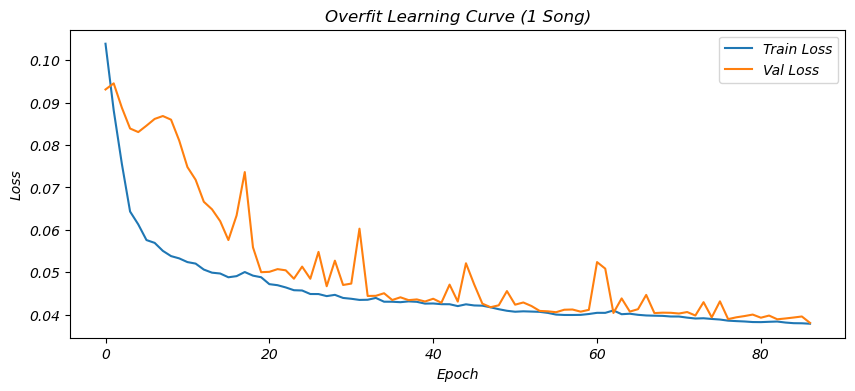

In [20]:
# Plot overfit learning curve from checkpoint or memory
overfit_ckpt_path = CHECKPOINT_DIR / "debug_overfit_1song.pth"

if overfit_ckpt_path.exists():
    utils.plot_loss_from_checkpoint(str(overfit_ckpt_path), title="Overfit Learning Curve (1 Song)")
elif history_overfit:
    utils.plot_loss_history(history_overfit, title="Overfit Learning Curve (1 Song)")
else:
    print("No overfit results available. Run the overfit training cell above.")

## 4. Model Architecture

View the U-Net model structure and parameter count.

In [21]:
# Model A architecture summary
model_summary = ma.TimeFrequencyDomainUNet(
    in_channels=1,
    out_channels=1,
    base_filters=64,
    num_layers=4
).to(device)
print(model_summary)
del model_summary

TimeFrequencyDomainUNet(
  (encoders): ModuleList(
    (0): EncoderBlock(
      (block): Sequential(
        (0): ConvLayer2D(
          (block): Sequential(
            (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU()
          )
        )
        (1): ConvLayer2D(
          (block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU()
          )
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncoderBlock(
      (block): Sequential(
        (0): ConvLayer2D(
          (block): Sequential(
            (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(128, eps=1e

## 5. Model Configuration

Configure model architecture and training hyperparameters.

In [22]:
# Get configurations from utils
MODEL_CONFIG = utils.get_model_a_config()
TRAIN_CONFIG = utils.get_training_config()

processor = utils.AudioProcessor(device=device)

model = ma.TimeFrequencyDomainUNet(
    in_channels=1,
    out_channels=1,
    base_filters=64,
    num_layers=4,
    batchnorm=True,
    dropout=0.1
).to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=TRAIN_CONFIG['learning_rate'])

print("Model A setup complete.")

Model A setup complete.


## 6. Full Training (Curriculum Learning)

Train the model on the full MUSDB18 dataset in two stages.

In [23]:
SKIP_TRAINING = False  # Set to True to skip full training

if not SKIP_TRAINING:
    # Check if checkpoints exist
    ckpt_s1 = CHECKPOINT_DIR / "full_stage1.pth"
    ckpt_s2 = CHECKPOINT_DIR / "full_stage2.pth"
    print(f"\n{'='*60}")
    print("Full Training: Curriculum Learning")
    print(f"{'='*60}")
    
    s1_exists = utils.check_checkpoint(ckpt_s1, "Stage 1 Checkpoint")
    s2_exists = utils.check_checkpoint(ckpt_s2, "Stage 2 Checkpoint")
    
    # Only train if data exists and checkpoints don't
    if len(mix_files_stage1) > 0 and len(mix_files_stage2) > 0:
        if not s1_exists or not s2_exists:
            print("\nStarting Full Training Pipeline...")
            hist_s1, hist_s2 = utils.run_full_training(
                model=model,
                processor=processor,
                optimizer=optimizer,
                loss_fn=loss_fn,
                train_config=TRAIN_CONFIG,
                cache_dir=str(DATA_DIR),
                save_path_stage1=str(ckpt_s1),
                save_path_stage2=str(ckpt_s2),
                device=device,
            )
        else:
            print("\n✅ Both checkpoints exist. Training skipped.")
            hist_s1, hist_s2 = {}, {}
    else:
        print("\n⚠️  No training data available. Skipping full training.")
        print("   Set DOWNLOAD_DATA = True to download MUSDB18 dataset.")
        hist_s1, hist_s2 = {}, {}
else:
    print("Skipping full training (SKIP_TRAINING = True)")
    hist_s1, hist_s2 = {}, {}


Full Training: Curriculum Learning
✅ Stage 1 Checkpoint found: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\checkpoints\full_stage1.pth
   Loading existing checkpoint instead of retraining.
✅ Stage 2 Checkpoint found: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning\checkpoints\full_stage2.pth
   Loading existing checkpoint instead of retraining.

✅ Both checkpoints exist. Training skipped.


## 7. View Training Results

Plot loss curves from saved checkpoint.

📁 Reading from: full_stage2_epochs
✅ Found 11 epochs

📊 Stats: Epochs=11 | Best Val=0.120200 (epoch 1)


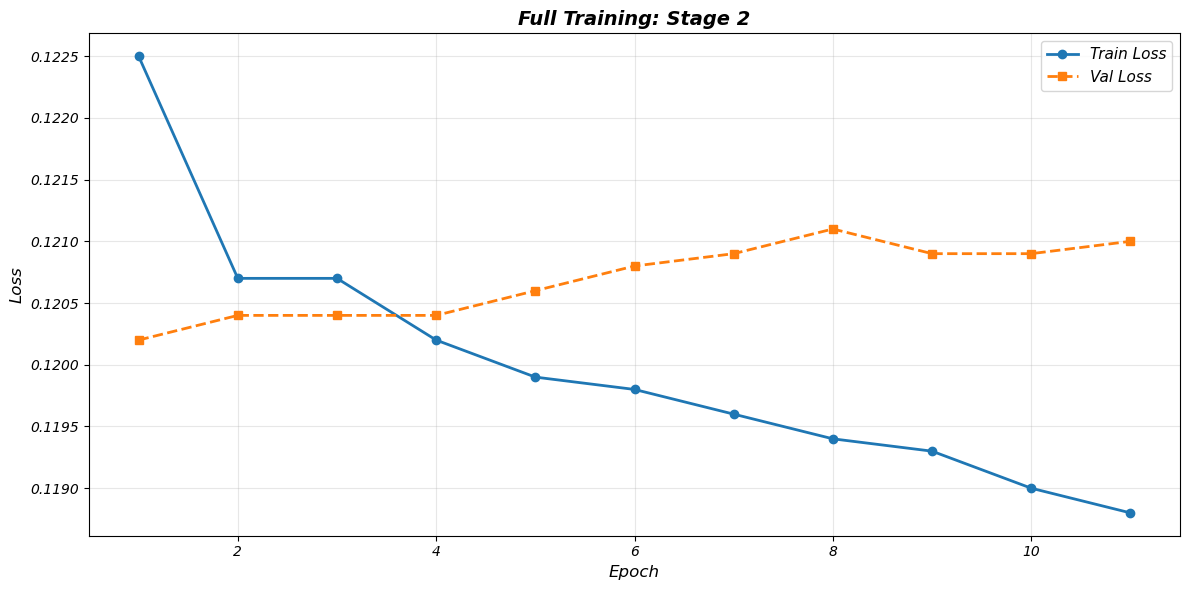

In [27]:
# Plot training curves - reads from epoch folders if available!
import re
import matplotlib.pyplot as plt
from pathlib import Path

stage2_ckpt = CHECKPOINT_DIR / "full_stage2.pth"
stage2_epochs_dir = CHECKPOINT_DIR / "full_stage2_epochs"

# Try epoch folder first (has complete history)
if stage2_epochs_dir.exists():
    print(f"📁 Reading from: {stage2_epochs_dir.name}")
    
    epoch_files = sorted(stage2_epochs_dir.glob("epoch_*.txt"))
    train_losses = []
    val_losses = []
    
    for epoch_file in epoch_files:
        with open(epoch_file, 'r') as f:
            content = f.read()
            train_match = re.search(r'Train Loss = ([\d.]+)', content)
            val_match = re.search(r'Val Loss = ([\d.]+)', content)
            if train_match and val_match:
                train_losses.append(float(train_match.group(1)))
                val_losses.append(float(val_match.group(1)))
    
    if train_losses:
        print(f"✅ Found {len(train_losses)} epochs\n")
        
        fig, ax = plt.subplots(figsize=(12, 6))
        epochs = range(1, len(train_losses) + 1)
        ax.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=6)
        ax.plot(epochs, val_losses, 's--', label='Val Loss', linewidth=2, markersize=6)
        ax.set_title("Full Training: Stage 2", fontsize=14, fontweight='bold')
        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        print(f"📊 Stats: Epochs={len(train_losses)} | Best Val={min(val_losses):.6f} (epoch {val_losses.index(min(val_losses))+1})")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Epoch files found but couldn't parse them")
        
elif stage2_ckpt.exists():
    utils.plot_loss_from_checkpoint(str(stage2_ckpt), title="Full Training: Stage 2")
elif hist_s2:
    utils.plot_loss_history(hist_s2, title="Full Training: Stage 2")
else:
    print("No training results available. Run the full training cell above.")

## 8. Listen to Separated Audio

Demo the model on MUSDB18 samples with audio playback and spectrograms.

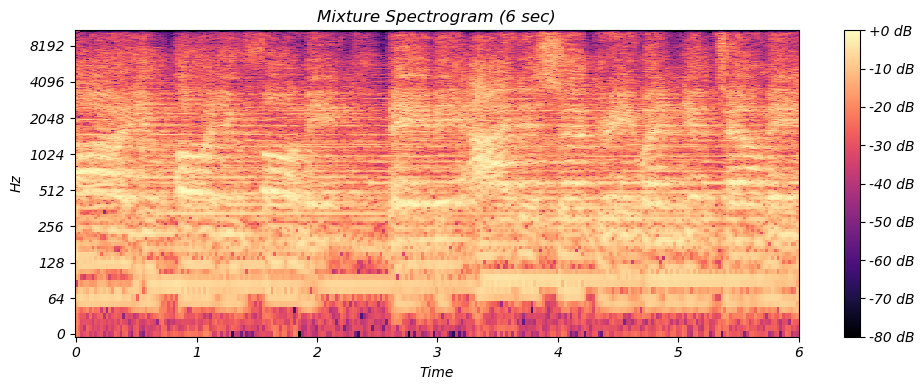

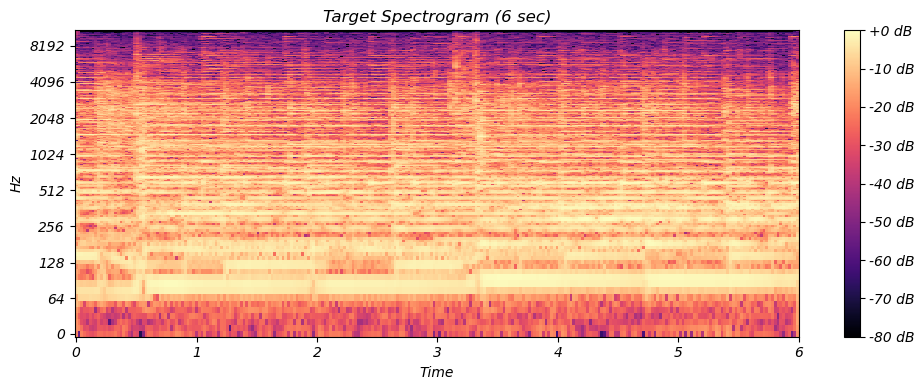

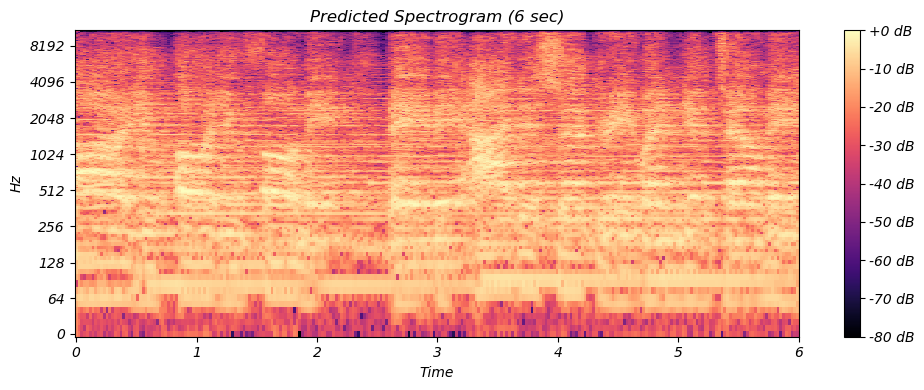

Mixture Audio (6 sec):


Target Audio (6 sec):


Predicted Audio (6 sec):


{'mix_wav': array([ 0.07633683,  0.1329729 ,  0.10267645, ..., -0.04987202,
        -0.02452156, -0.01223302], dtype=float32),
 'tgt_wav': array([-0.03952871, -0.04942799, -0.03597834, ..., -0.00730355,
        -0.02939679, -0.05559306], dtype=float32),
 'est_wav': array([[-0.00822093,  0.01965267,  0.00903438, ...,  0.02244428,
          0.01727392,  0.00597163]], dtype=float32),
 'mix_mag': tensor([[[4.3524e-01, 2.8159e-01, 8.7244e-02,  ..., 3.6150e-02,
           7.4148e-02, 6.2236e-02],
          [4.3882e-01, 2.0104e-01, 1.1190e-01,  ..., 1.1212e-01,
           1.5730e-01, 9.8464e-02],
          [4.4000e-01, 2.8117e-01, 1.1570e-01,  ..., 2.6650e-01,
           1.8916e-01, 1.7037e-01],
          ...,
          [8.6997e-02, 4.4443e-02, 1.5161e-06,  ..., 1.7781e-06,
           2.8415e-03, 1.2305e-02],
          [8.6987e-02, 4.4438e-02, 3.1822e-07,  ..., 8.4057e-07,
           2.8414e-03, 1.2298e-02],
          [8.6983e-02, 4.4435e-02, 1.1027e-06,  ..., 7.4133e-07,
           2.8412e-0

In [25]:
# Preview a sample separation from the cache
utils.demo_separation_sample(
    model=model,
    processor=processor,
    cache_dir=str(DATA_DIR),
    stage="stage1",
    song_num=12,
    duration=6,
    sr=22050,
    device=device,
    play_audio_output=True,
 )

In [26]:
import os, sys
print('Current working directory:', os.getcwd())
print('sys.path:', sys.path)
print('Directory listing:', os.listdir('.'))

Current working directory: c:\Users\amita\source\repos\Deep learning on computational accelerators\Final_Project_Deep_Learning
sys.path: ['c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\python39.zip', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\DLLs', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\lib', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env', '', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\lib\\site-packages', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\lib\\site-packages\\win32', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\lib\\site-packages\\win32\\lib', 'c:\\Users\\amita\\anaconda3\\envs\\final-dl-env\\lib\\site-packages\\Pythonwin', 'c:\\Users\\amita\\source\\repos\\Deep learning on computational accelerators\\Final_Project_Deep_Learning']
Directory listing: ['.git', '.gitignore', 'checkpoints', 'data', 'environment.yml', 'Latex_and_PDFs', 'local_main.ipynb', 'models', 'README.md']


# Model B2: [Architecture Name]

[Description of Model B2]

# Model B1: [Architecture Name]

[Description of Model B1]